# Notebook \#5: Curve Simplification
#### by Sebastian Einar Salas Røkholt

---


**Index**  
- [**1 - Introduction and Setup**](#1---introduction-and-setup)  
  - [*1.1 Setup*](#11-setup)  
  - [*1.2 Load the Anomaly Detection Model*](#12-load-the-forecasting-model)  
  - [*1.3 Data Preparation*](#13-data-preparation)  
- [**2 - Chapter 2**](#2---chapter-2)  
  - [*2.1 ....*](#21-....)  

---

## 1 - Introduction and Setup
The aim of this notebook is to produce and plot an ORS simplification of a single charging session's power curve.
We tune the ORS terms/parameters on the validation set, then apply ORS to a test session.


## 1.1 Setup

In [1]:
import os
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mt4xai.data import split_data, apply_scalers, build_loader, fit_scalers_on_train
from mt4xai.model import load_lstm_model

RANDOM_SEED = 42

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
CLEANED_DATA_PATH = os.path.join(PROJECT_ROOT, "Data", "etron55-charging-sessions.parquet")

FINAL_MODEL_FOLDER_PATH = os.path.join(PROJECT_ROOT, "Models/final")
FINAL_MODEL_PATH = os.path.join(FINAL_MODEL_FOLDER_PATH, "final_model.pth")


print("[env] CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("[env] Device:", torch.cuda.get_device_name(torch.cuda.current_device()))
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

%matplotlib inline

[env] CUDA available: True
[env] Device: NVIDIA GeForce RTX 4070 Laptop GPU


### 1.2 Load the Forecasting Model

In [2]:
# Loads a trained LSTM model from disk
model, checkpoint = load_lstm_model(FINAL_MODEL_PATH, device=DEVICE)

input_features  = checkpoint["input_features"]
target_features = checkpoint["target_features"]
cfg = checkpoint["config"]
HORIZON = int(cfg["horizon"])
POWER_WEIGHT = float(cfg.get("power_weight", 0.5))

# Indices of targets within the *input* feature vector (used for reconstruction)
idx_power_inp = input_features.index("power")
idx_soc_inp   = input_features.index("soc")

/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/src/mt4xai/model.py:45: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch

### 1.3 Data Preparation
In this section, we will load, transform, and split the data in exactly the same way as we did previously in order to extract the test set for running anomaly detection tests.

In [3]:
# Loads the cleaned data (already wrangled)
df_cleaned = pd.read_parquet(CLEANED_DATA_PATH)  # TODO: Replace with raw data and apply wrangling pipeline
# Removes features that aren't used to classify charging sessions
df = df_cleaned.drop(labels=['energy', 'charger_category', 'timestamp', 
                             'nearest_weather_station', 'timestamp_d', 'lat', 'lon', 'timestamp_H'], axis=1).copy()

# Split exactly like the modelling notebook
train_df, val_df, test_df = split_data(df, test_size=0.2, validation_size=0.1)

# Fit scalers on train and apply to val/test (same as modelling)
cols_to_scale = list(set(input_features) | set(target_features))
scalers = fit_scalers_on_train(train_df, cols_to_scale)
power_scaler, soc_scaler = scalers["power"], scalers["soc"]  # Extract for later use
train_s = apply_scalers(train_df, scalers)
val_s = apply_scalers(val_df, scalers)
test_s = apply_scalers(test_df, scalers)

# Builds the DataLoaders to iterate over charging sessions
val_loader = build_loader(val_s,  input_features, target_features, HORIZON, batch_size=16, shuffle=False, num_workers=0)
test_loader = build_loader(test_s, input_features, target_features, HORIZON, batch_size=16, shuffle=False, num_workers=0)

## 2 - Optimal Robust Simplifications (ORS)

### 2.1 Running ORS

Internally this computes Macro-RMSE per perturbation in one forward pass, using the reconstruction and inverse-transform helpers; it weights horizons by λ = 0.2 and compares to thr = 8.5962.

In [68]:
# selects a charging session from the validation set
from mt4xai.data import fetch_session_preds_bundle

# SESSION_ID = 7753775 # abnormal
# SESSION_ID = 7419257  # normal, in val set
# SESSION_ID = 11732342  # abnormal
SESSION_ID = 5649864  # abnormal
# SESSION_ID = 4468530  # abnormal
SESSION_ID = 7554450
SESSION_ID = 8203265
bundle_test = fetch_session_preds_bundle(model, test_loader, device=DEVICE, power_scaler=power_scaler, soc_scaler=soc_scaler,
                                        idx_power_inp=idx_power_inp, idx_soc_inp=idx_soc_inp,
                                        batch_index=None, sample_index=None, session_id=SESSION_ID)

# TEST_BATCH_IDX, TEST_SAMPLE_IDX = 300, 5   # abnormal session with large jump in the beginning
# TEST_BATCH_IDX, TEST_SAMPLE_IDX = 300, 5   # increase batch index for longer sessions

# bundle_test = fetch_session_preds_bundle(model, test_loader, TEST_BATCH_IDX, TEST_SAMPLE_IDX, DEVICE,
#                                  power_scaler, soc_scaler, idx_power_inp, idx_soc_inp)
T = bundle_test.length
print(f"[info] test bundle -> T={T}, H={bundle_test.horizon}, session_id={bundle_test.session_id}")


[info] test bundle -> T=60, H=5, session_id=8203265


[DP] k=6, frag=0.000000, objective=11.969


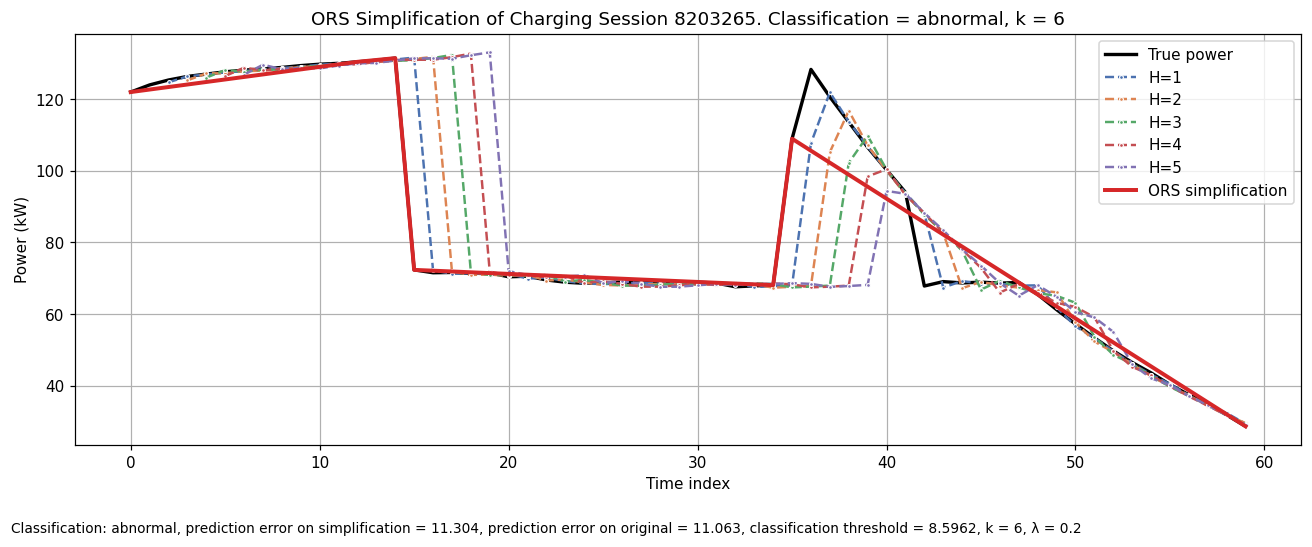

abnormal
1


In [69]:
from mt4xai.ors import ORSParams, ors_optimal_mrmse, base_label_from_bundle
from mt4xai.plot import plot_session_with_simplification
# macro-rmse params
LAMBDA_DECAY = 0.2
MRC_THRESHOLD = 8.5962

# common ORS settings
common_params = dict(alpha=0.001, beta=2.0, gamma=0.1,
                     R=1000, epsilon_mode="fraction", epsilon_value=0.1,
                     enforce_same_label=True, q=250, stage1_candidates=20, 
                     t_min_eval=1, min_k=1, max_k=15)

# run with DP 
dp_params = ORSParams(stage1_mode="dp", **common_params)
res_dp = ors_optimal_mrmse(bundle_test, model, dp_params,
                           power_scaler=power_scaler, soc_scaler=soc_scaler,
                           idx_power_inp=idx_power_inp, idx_soc_inp=idx_soc_inp,
                           power_weight=POWER_WEIGHT, decay_lambda=LAMBDA_DECAY,
                           threshold=MRC_THRESHOLD)


# Fetches the error for the original session for plotting purposes
base_lbl, base_err, _ = base_label_from_bundle(
    bundle_test,
    power_scaler=power_scaler, soc_scaler=soc_scaler,
    idx_power_inp=idx_power_inp, idx_soc_inp=idx_soc_inp,
    power_weight=POWER_WEIGHT, decay_lambda=LAMBDA_DECAY,
    t_min_eval=dp_params.t_min_eval, threshold=MRC_THRESHOLD
)

print(f"[DP] k={res_dp['k']}, frag={res_dp['frag']:.6f}, objective={res_dp['obj']:.3f}")
plot_session_with_simplification(bundle_test, power_scaler, soc_scaler,
                                 idx_power_inp, idx_soc_inp,
                                 res_dp['sts'], session_id=bundle_test.session_id,
                                 k=res_dp['k'], threshold=MRC_THRESHOLD,
                                 simp_error=res_dp['err'], orig_error=base_err, label=res_dp['label'],
                                 decay_lambda=LAMBDA_DECAY, t_min_eval=dp_params.t_min_eval)

print(res_dp["label"])
print(base_lbl)

In [70]:
# what k did stage-1 actually generate?
from mt4xai.ors import ors_candidates
y = np.asarray(bundle_test.true_power_unscaled, float)
cands = ors_candidates(y, dp_params)
print("count by k:", {len(piv)-1:0 for _,piv in cands})
for cost,piv in cands[:10]:
    print(f"k={len(piv)-1}, cost_es={cost:.4f}")


count by k: {6: 0, 5: 0, 7: 0}
k=6, cost_es=11.9693
k=6, cost_es=11.9694
k=6, cost_es=11.9705
k=6, cost_es=11.9722
k=6, cost_es=11.9726
k=6, cost_es=11.9746
k=6, cost_es=11.9762
k=6, cost_es=11.9768
k=6, cost_es=11.9771
k=6, cost_es=11.9783


In [71]:
import numpy as np
from mt4xai.ors import ors_candidates, base_label_from_bundle, classify_macro_rmse_from_power

# stage-1 candidates (which k’s DP/RDP produced)
y = np.asarray(bundle_test.true_power_unscaled, dtype=float)
cands = ors_candidates(y, dp_params)  # or rdp_params
k_stage1 = sorted({len(piv) - 1 for _, piv in cands})
print("Stage-1 ks:", k_stage1)

# which k’s passed the stage-2 prefilter (min_k/max_k + same-label if enforced)
base_lbl, base_err, Y_abs_true = base_label_from_bundle(
    bundle_test, power_scaler=power_scaler, soc_scaler=soc_scaler,
    idx_power_inp=idx_power_inp, idx_soc_inp=idx_soc_inp,
    power_weight=POWER_WEIGHT, decay_lambda=LAMBDA_DECAY,
    t_min_eval=dp_params.t_min_eval, threshold=MRC_THRESHOLD
)

T = bundle_test.length
k_stage2 = []
for _, piv in cands:
    k = len(piv) - 1
    if not (dp_params.min_k <= k <= dp_params.max_k):
        continue
    sts = np.interp(np.arange(T), piv, y[piv])
    lbl_sts, _ = classify_macro_rmse_from_power(
        bundle_test, model, sts,
        power_scaler=power_scaler, soc_scaler=soc_scaler,
        idx_power_inp=idx_power_inp, idx_soc_inp=idx_soc_inp,
        power_weight=POWER_WEIGHT, decay_lambda=LAMBDA_DECAY,
        t_min_eval=dp_params.t_min_eval, Y_abs_true=Y_abs_true, threshold=MRC_THRESHOLD
    )
    if (not dp_params.enforce_same_label) or (lbl_sts == base_lbl):
        k_stage2.append(k)

print("Stage-2 evaluated ks:", sorted(set(k_stage2)))


Stage-1 ks: [5, 6, 7]
Stage-2 evaluated ks: [5, 6, 7]


[RDP] k=13, frag=0.000, objective=173.826


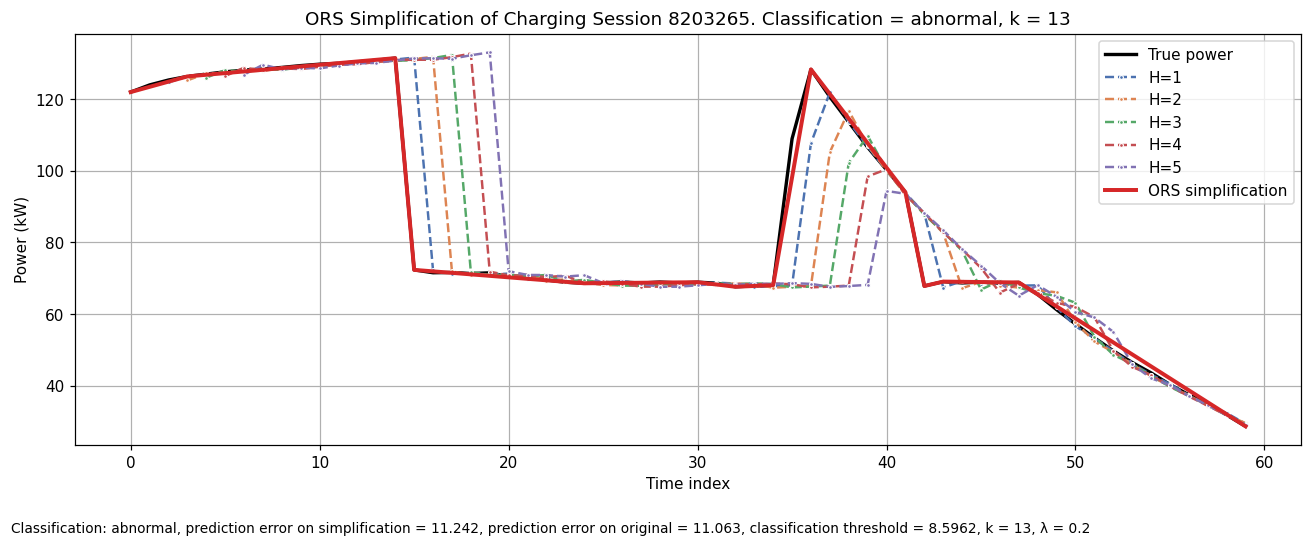

In [72]:
# --- run with RDP (fast heuristic)
rdp_params = ORSParams(stage1_mode="rdp", **common_params)
res_rdp = ors_optimal_mrmse(bundle_test, model, rdp_params,
                            power_scaler=power_scaler, soc_scaler=soc_scaler,
                            idx_power_inp=idx_power_inp, idx_soc_inp=idx_soc_inp,
                            power_weight=POWER_WEIGHT, decay_lambda=LAMBDA_DECAY,
                            threshold=MRC_THRESHOLD)

print(f"[RDP] k={res_rdp['k']}, frag={res_rdp['frag']:.3f}, objective={res_rdp['obj']:.3f}")
plot_session_with_simplification(bundle_test, power_scaler, soc_scaler,
                                 idx_power_inp, idx_soc_inp,
                                 res_rdp['sts'], session_id=bundle_test.session_id,
                                 k=res_rdp['k'], threshold=MRC_THRESHOLD,
                                 simp_error=res_rdp['err'], orig_error=base_err, label=res_rdp['label'],
                                 decay_lambda=LAMBDA_DECAY, t_min_eval=rdp_params.t_min_eval)
